# Notebook 04 — Biểu đồ & Lưu kết quả
**Nhóm 67 | Tuần 2**

Vẽ 2 biểu đồ bắt buộc và lưu toàn bộ kết quả lên Drive.

> Chạy notebook 02 và 03 trước.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json, ast, os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

BASE = Path("/content/drive/MyDrive/Project")
OUT_DIR = BASE / "results"

with open(OUT_DIR / "student_simulation.json", encoding="utf-8") as f:
    sim = json.load(f)
rows = sim["submissions"]

print(f"✓ Đọc {len(rows)} submissions")

✓ Đọc 12 submissions


## Biểu đồ 1 — Test Pass Rate: Public vs Hidden (RQ1)

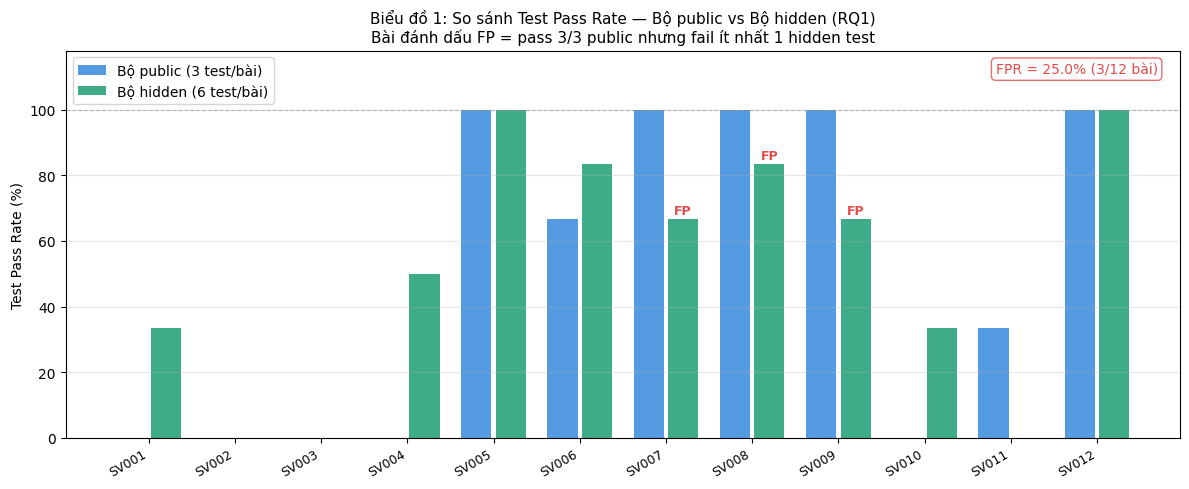

✓ Lưu: /content/drive/MyDrive/Project/results/bieu_do_1_tpr.png


In [3]:
ids  = [r["sv_id"]   for r in rows]
pub  = [r["pub_tpr"] for r in rows]
hid  = [r["hid_tpr"] for r in rows]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(ids))

ax.bar([i - 0.2 for i in x], pub, 0.35,
       label="Bộ public (3 test/bài)", color="#378ADD", alpha=.85)
ax.bar([i + 0.2 for i in x], hid, 0.35,
       label="Bộ hidden (6 test/bài)", color="#1D9E75", alpha=.85)

for i, r in enumerate(rows):
    if r["is_false_positive"]:
        ax.annotate("FP", xy=(i + 0.2, hid[i] + 1.5),
                    ha="center", fontsize=9,
                    color="#E24B4A", fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(ids, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Test Pass Rate (%)")
ax.set_title(
    "Biểu đồ 1: So sánh Test Pass Rate — Bộ public vs Bộ hidden (RQ1)\n"
    "Bài đánh dấu FP = pass 3/3 public nhưng fail ít nhất 1 hidden test",
    fontsize=11
)
ax.legend(fontsize=10)
ax.set_ylim(0, 118)
ax.axhline(100, ls="--", color="gray", lw=0.8, alpha=0.5)
ax.grid(axis="y", alpha=0.3)

fp_total  = sim["fp_count"]
fpr_total = sim["fpr_rate_%"]
ax.text(0.98, 0.97,
        f"FPR = {fpr_total}% ({fp_total}/{len(rows)} bài)",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="#E24B4A",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#E24B4A", alpha=0.8))

plt.tight_layout()
plt.savefig(OUT_DIR / "bieu_do_1_tpr.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {OUT_DIR / 'bieu_do_1_tpr.png'}")

## Biểu đồ 2 — Phân loại lỗi: Public vs Hidden (RQ3)

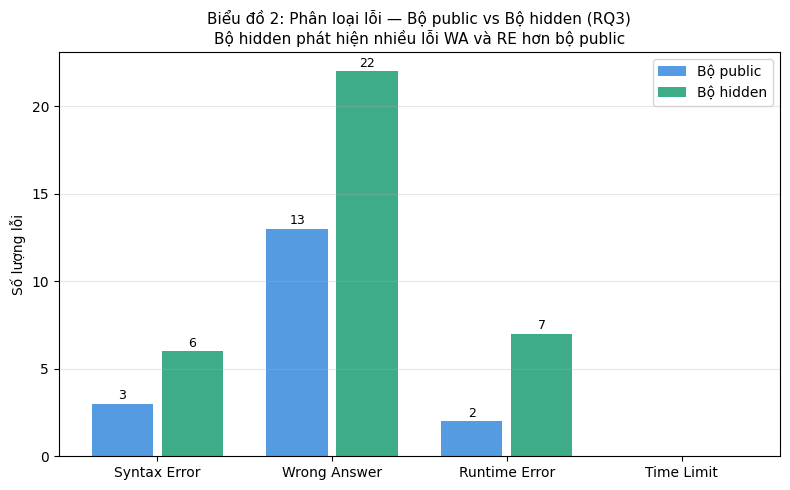

✓ Lưu: /content/drive/MyDrive/Project/results/bieu_do_2_loi.png


In [4]:
from collections import Counter

def count_errors(col):
    c = Counter()
    for r in rows:
        try:
            d = ast.literal_eval(r[col])
        except Exception:
            d = {}
        for k, v in d.items():
            c[k] += v
    return c

pub_err = count_errors("pub_errors")
hid_err = count_errors("hid_errors")

labels  = ["SE", "WA", "RE", "TLE"]
xlabels = ["Syntax Error", "Wrong Answer", "Runtime Error", "Time Limit"]
pub_v   = [pub_err.get(k, 0) for k in labels]
hid_v   = [hid_err.get(k, 0) for k in labels]

fig, ax = plt.subplots(figsize=(8, 5))
xb = range(len(labels))

b1 = ax.bar([i - 0.2 for i in xb], pub_v, 0.35,
            label="Bộ public", color="#378ADD", alpha=.85)
b2 = ax.bar([i + 0.2 for i in xb], hid_v, 0.35,
            label="Bộ hidden", color="#1D9E75", alpha=.85)

for bar in b1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
for bar in b2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(xb))
ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("Số lượng lỗi")
ax.set_title(
    "Biểu đồ 2: Phân loại lỗi — Bộ public vs Bộ hidden (RQ3)\n"
    "Bộ hidden phát hiện nhiều lỗi WA và RE hơn bộ public",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "bieu_do_2_loi.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {OUT_DIR / 'bieu_do_2_loi.png'}")

#BIỂU ĐỒ DESCRIPTION VÀ SỐ TESTCASE/BÀI

✓ Data: mbpp_clean.json (15 bai)


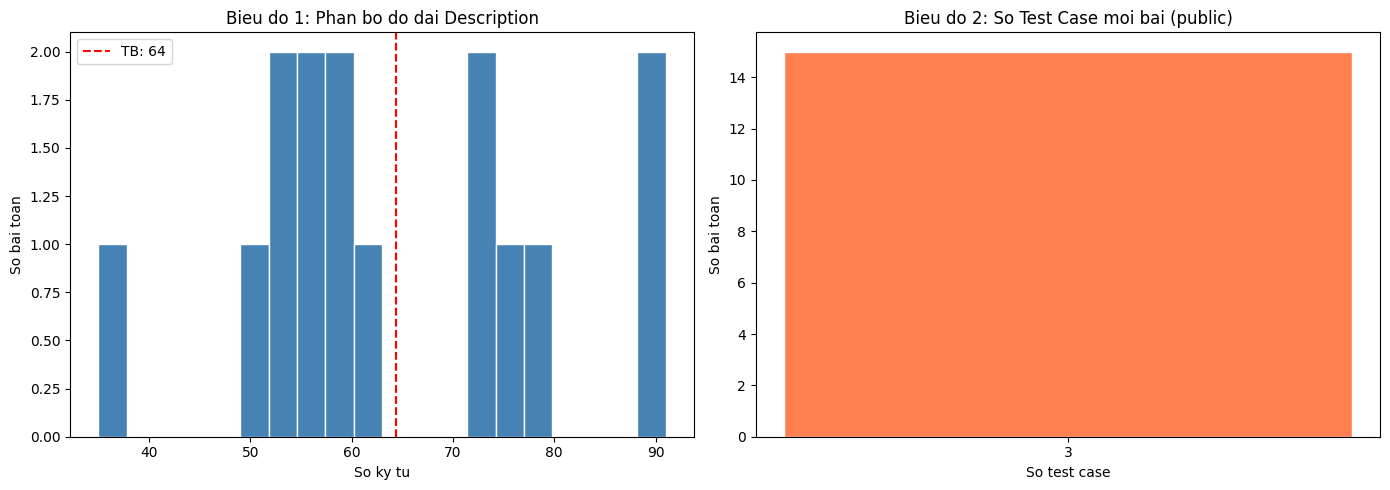

✅ Da luu bieu do vao results/


In [5]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"



data_path = BASE / "data" / "processed" / "mbpp_clean.json"

with open(data_path, encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df["desc_length"] = df["text"].fillna("").apply(len)

def _count_public_tests(row):
    pub = row.get("public_tests") or row.get("test_list") or []
    return len(pub)

df["num_tests"] = df.apply(_count_public_tests, axis=1)
print(f"✓ Data: {data_path.name} ({len(df)} bai)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["desc_length"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Bieu do 1: Phan bo do dai Description")
axes[0].set_xlabel("So ky tu")
axes[0].set_ylabel("So bai toan")
axes[0].axvline(df["desc_length"].mean(), color="red", linestyle="--",
                label=f"TB: {df['desc_length'].mean():.0f}")
axes[0].legend()

test_counts = df["num_tests"].value_counts().sort_index()
axes[1].bar(test_counts.index.astype(str), test_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Bieu do 2: So Test Case moi bai (public)")
axes[1].set_xlabel("So test case")
axes[1].set_ylabel("So bai toan")

plt.tight_layout()

(BASE / "results").mkdir(parents=True, exist_ok=True)

plt.savefig(BASE / "results" / "data_analysis.png", dpi=150)
plt.show()
print("✅ Da luu bieu do vao results/")

## Lưu toàn bộ kết quả lên Google Drive

In [6]:
import shutil

EXPORT_DIR = OUT_DIR / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Thêm 'data_analysis.png' vào danh sách file cần xuất
files = [
    "bieu_do_1_tpr.png",
    "bieu_do_2_loi.png",
    "data_analysis.png",
    "baseline_summary.csv",
    "student_simulation.csv",
    "student_simulation.json",
    "metric_summary.json",
]

for fname in files:
    src = OUT_DIR / fname
    dst = EXPORT_DIR / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"  ✓ {fname}")
    else:
        print(f"  ✗ Chưa có: {fname} — hãy đảm bảo bạn đã chạy các ô code tạo file này")

print(f"\n✅ Đã lưu toàn bộ vào: {EXPORT_DIR}")

  ✓ bieu_do_1_tpr.png
  ✓ bieu_do_2_loi.png
  ✓ data_analysis.png
  ✓ baseline_summary.csv
  ✓ student_simulation.csv
  ✓ student_simulation.json
  ✓ metric_summary.json

✅ Đã lưu toàn bộ vào: /content/drive/MyDrive/Project/results/exports
